In [1]:
import numpy as np
import pandas as pd
from utils import plot_training_metrics, plot_training_comparison, distribution_comparison, reward_comparison
from environment import agentDLVEnvV1
import os
import shutil
import random
import torch
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.callbacks import CallbackList
from ReLuExtractor import ReLUFeatureExtractor

In [2]:
df = pd.read_csv('weth_test_data_expanded.csv')
nav = df['nav'].values
volatile_part = df['weth_frac'].values
nect_price = df['nect_price'].values

nav = nav
volatile_part = volatile_part
nect_price = nect_price

SCALE = 100
LEARNING_EPOCHS = 2*1024*300 #default 200
TARGET_LEVERAGE = 3
SEED = 400
THREADS = 4
nav = nav/SCALE


In [3]:
def make_calm(i):
    def _init():
        env = agentDLVEnvV1(
            nect_honey_price = nect_price,
            LP_nav_honey = nav,
            volatile_part = volatile_part,
            is_training = True,
            target_leverage = TARGET_LEVERAGE
        )
        return Monitor(env)
    return _init

def make_vol(i):
    def _init():
        env = agentDLVEnvV1(
            nect_honey_price = nect_price,
            LP_nav_honey = nav,
            volatile_part = volatile_part,
            is_training = True,
            target_leverage = TARGET_LEVERAGE
        )
        return Monitor(env)
    return _init

vec_env = DummyVecEnv([make_calm(0), make_vol(0)])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True)

policy_kwargs = dict(
    features_extractor_class=ReLUFeatureExtractor,
    features_extractor_kwargs=dict(features_dim=64)
)


model_1 = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=1e-5,  
    ent_coef=1e-4,       
    verbose=1,
    policy_kwargs=policy_kwargs,
    n_steps=1024,
    vf_coef = 1,
    device="cpu" 
)

model_1.set_parameters("loop_model_weth/ppo_model_final.zip")

Using cpu device


c:\Proga\leverege_simul\for_server\utils.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[5].legend()


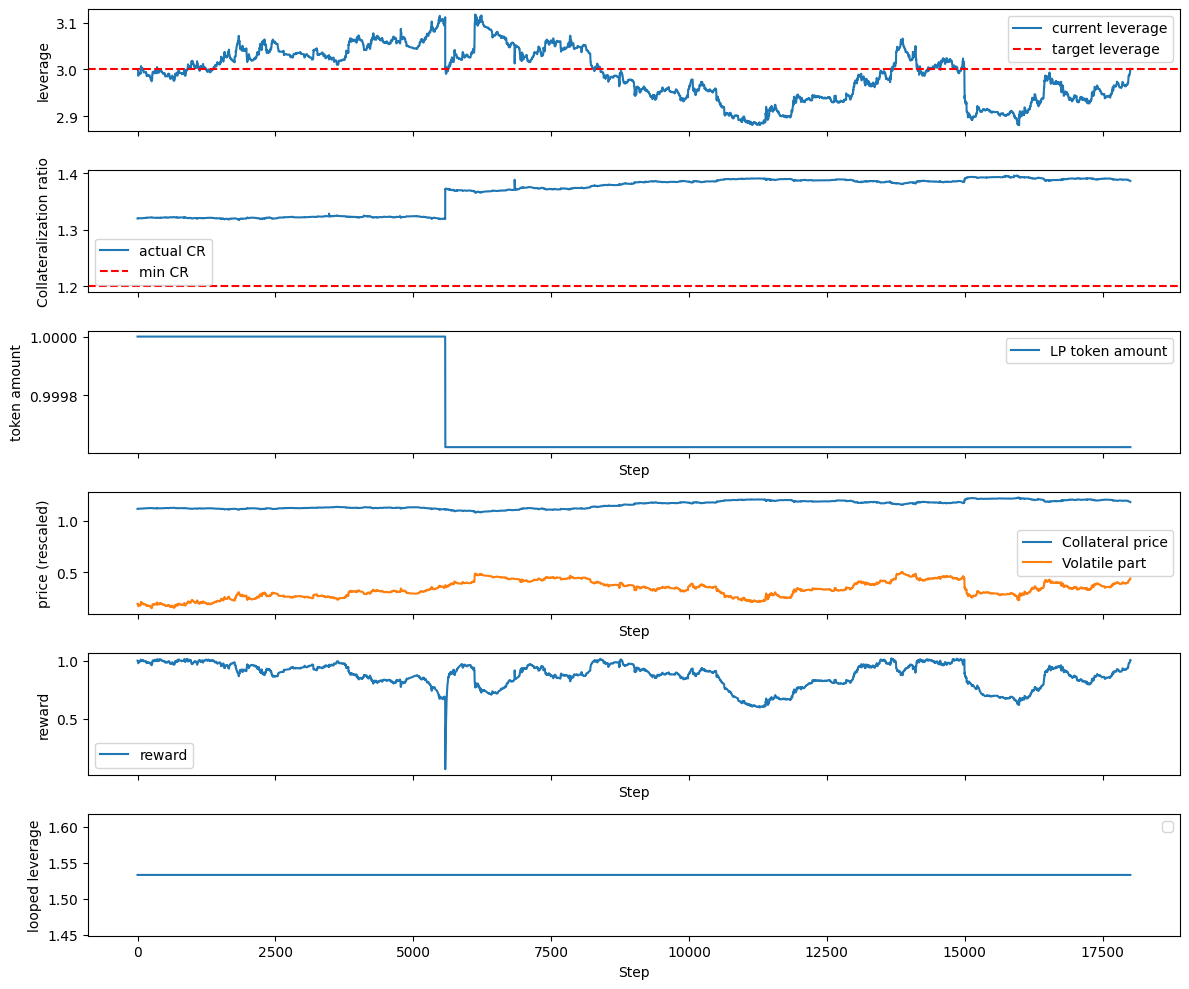

In [4]:
eval_env_vol = DummyVecEnv([lambda: agentDLVEnvV1(
    nect_honey_price = nect_price,
    LP_nav_honey = nav,
    volatile_part = volatile_part,
    is_training=False,
    target_leverage=TARGET_LEVERAGE
)])
eval_env_vol = VecNormalize.load("loop_model_weth/vecnormalize_stats.pkl", eval_env_vol)
eval_env_vol.training = False
eval_env_vol.norm_reward = False

obs = eval_env_vol.reset()   
done = False
while not done:
    action, _ = model_1.predict(obs, deterministic=True)  
    obs, rewards, dones, infos = eval_env_vol.step(action)
    done = dones[0]
    if dones[0]:
        vol_episode_history = infos[0].get('episode_history')   
        break


history_vol_1 = vol_episode_history 

plot_training_metrics(history_vol_1, show_loop=True, target_leverage=TARGET_LEVERAGE)

In [5]:
def naiveAgent(obs, target_leverage = 2, max_step = 0.15, deviation = 0.01):

    nect = obs[0]
    leverage = obs[3] + target_leverage
    colateral_value = obs[1]
    volatile_part_value = obs[2]

    if abs(leverage - target_leverage)/target_leverage<=deviation:
        return 0
    else: 
        return 1

In [6]:
eval_env_vol = agentDLVEnvV1(
    nect_honey_price = nect_price, 
    LP_nav_honey = nav, 
    volatile_part = volatile_part,
    target_leverage=TARGET_LEVERAGE
)

obs, _ = eval_env_vol.reset()
done = False
while not done:
    action = naiveAgent(obs, deviation=0.05)
    obs, reward, _, done, _ = eval_env_vol.step(action)

history_vol, _ = eval_env_vol.get_history()

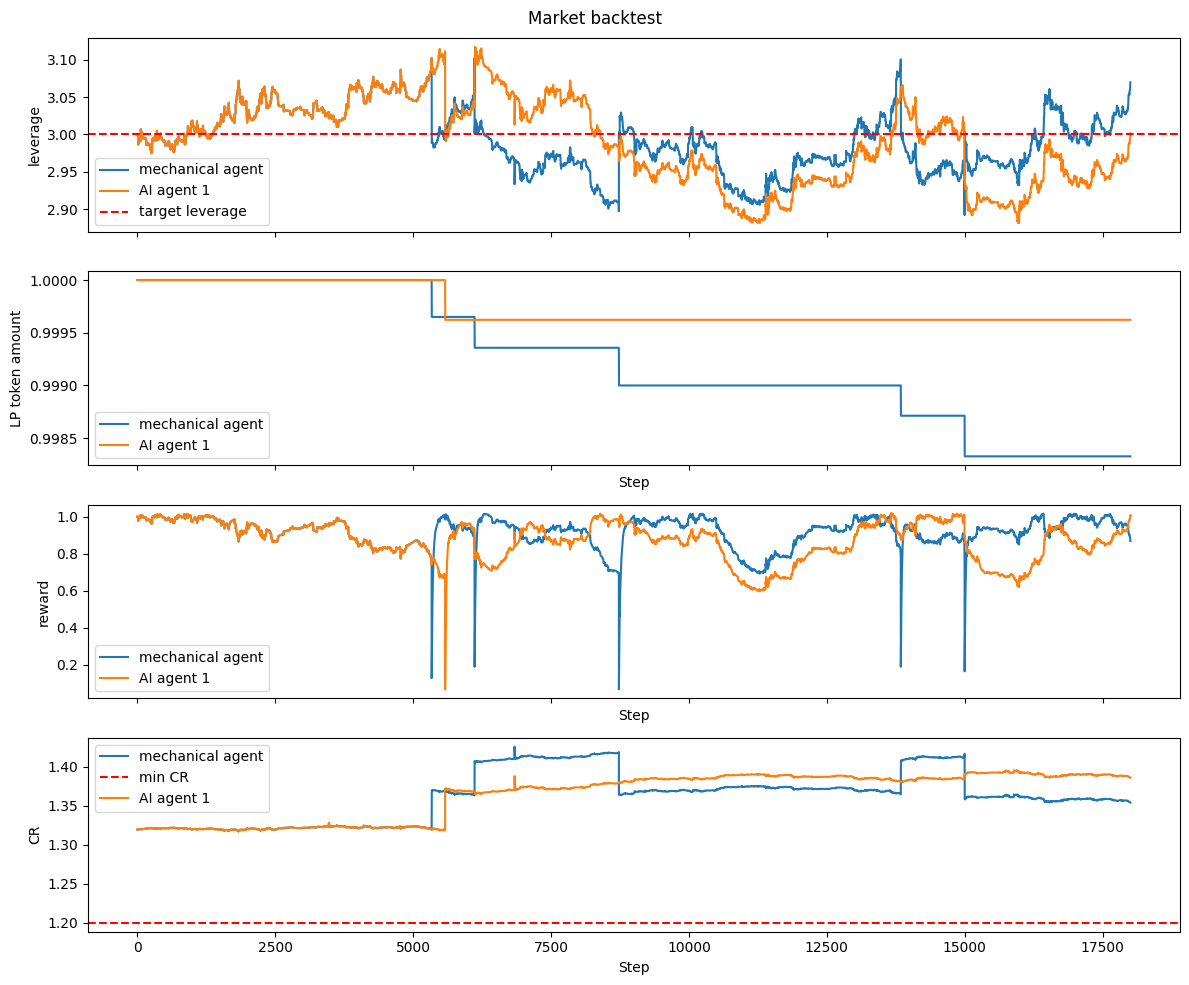

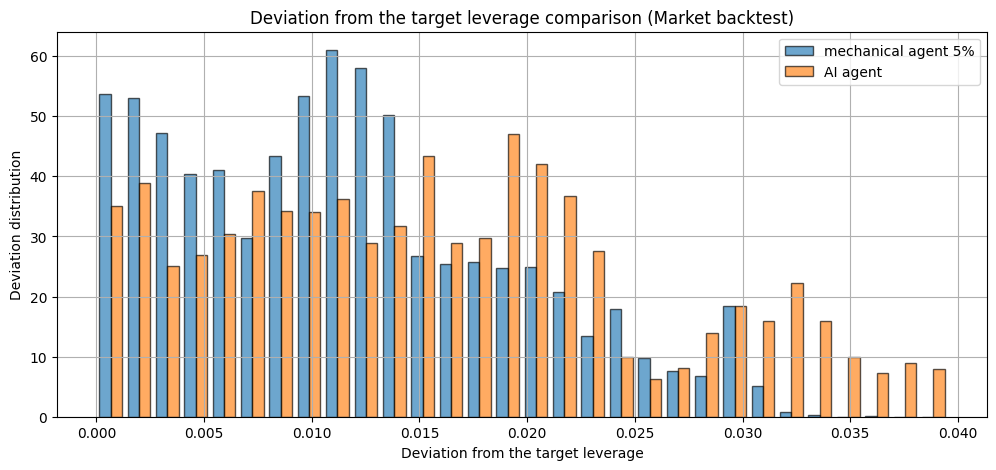

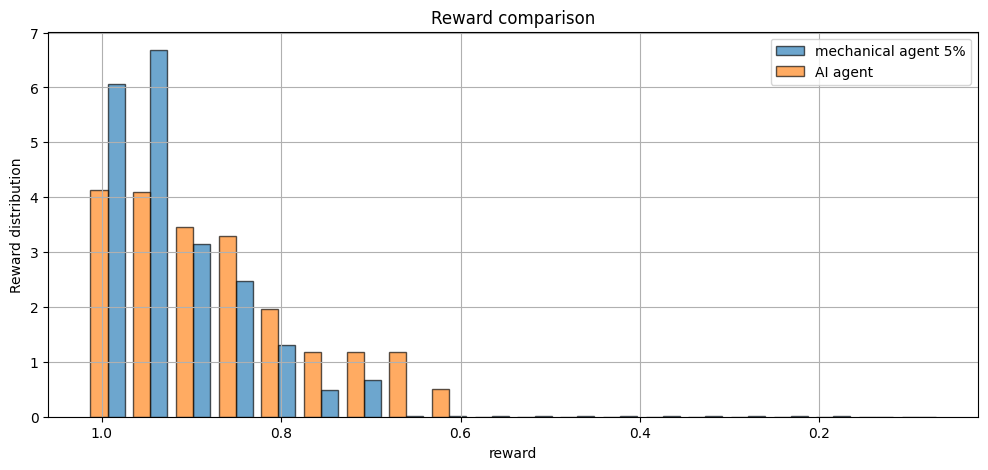

In [7]:
plot_training_comparison(history_vol, [history_vol_1], 'Market backtest', target_leverage=TARGET_LEVERAGE)

distribution_comparison(
    [history_vol, history_vol_1],
    ['mechanical agent 5%', 'AI agent'],
    'Market backtest',
    target_leverage = TARGET_LEVERAGE
)

reward_comparison(
    [history_vol, history_vol_1],
    ['mechanical agent 5%', 'AI agent']
)